# Time-Dependent S21 Measurement Data Handling

This notebook performs the following steps:
1. **Organize & Rename** raw sweep CSV files -> 3-column CSV files
2. **Trim** visually identify the stable onset and discard early sweeps (it is usually happened when the temperature is not actually stable but the measurement starts performing.)
3. **Fit** each sweep with the DCM circle fit to extract Qi, Qc, fc
4. **PSD analysis** of the fit parameters using Welch's method

## Section 0 — Imports & Path Setup

In [ ]:
import sys
import re
import shutil
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy import signal as sig

matplotlib.rcParams['figure.dpi'] = 100

# Point this to the local clone of Fitting_Code_Lab_2.0 
FITTING_CODE_DIR = Path(r"C:\Users\user\Documents\GitHub\Fitting_Code_Lab_2.0")

sys.path.insert(0, str(FITTING_CODE_DIR / "helper_scripts"))
sys.path.insert(0, str(FITTING_CODE_DIR / "scresonators"))

import helper_fit as hf

print("All imports successful.")

## Section 1 — Organize Measured Files

**Input** – a flat source directory containing CSV VNA sweep files directly, e.g.:
```
QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0.csv       <- 3-col, with header
QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0_full.csv  <- 13-col, with measurement details, skip the files later
QSD_CPW_w6g3_03_5p608GHz_-40dBm_15mK_0.csv
...
```

The CSV files already contain the 3 columns required by the fitting code
(Frequency Hz, S21 magn_dB, S21 phase_deg) with a header row.

**Output** – organized folder `{target_dir}/{res_label}_{freq_str}/`
with the same files copied in plus a `metadata.csv`.

In [ ]:
# User Configuration
source_dir = Path(r"C:\Users\user\Downloads\15mK_Time_Dependent_S21\15mK_Time_Dependent_S21\06_10_174033")
target_dir = Path(r"C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_78_Line1-HTCav_01_CPW_w50g25_03")
res_label  = "Resonator_1"

if not source_dir.exists():
    raise FileNotFoundError(f"Source directory not found: {source_dir}")
print(f"Source dir : {source_dir}")
print(f"Target dir : {target_dir}")
print(f"Resonator  : {res_label}")

In [ ]:
# Helper: parse the new filename format
#
# Expected stem: {sample_name}_{freq_str}_{power_str}_{temperature}_{index}
# Example      : QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0
#
# The regex anchors on the known-format suffix and lets sample_name float.
# _full files are excluded naturally because their stem ends with '_full',
# not a digit, so the regex simply does not match them.

_FILE_RE = re.compile(
    r'^(.+?)_([ \dp]+GHz)_([-\dp]+dBm)_(\w+?)_(\d+)$'
)

def parse_sweep_file(stem: str) -> dict | None:
    """Parse a sweep CSV stem. Returns None for non-matching names (_full etc.)."""
    m = _FILE_RE.match(stem)
    if not m:
        return None
    sample, freq_str, power_str, temperature, idx = m.groups()
    return {
        'sample_name' : sample,
        'freq_str'    : freq_str,
        'power_str'   : power_str,
        'temperature' : temperature,
        'file_index'  : int(idx),
    }

print("Helper function defined.")

# Quick self-test
_test_cases = [
    ("QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0",      True),
    ("QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0_full", False),
]
for stem, expect_match in _test_cases:
    result = parse_sweep_file(stem)
    ok = (result is not None) == expect_match
    print(f"  {'OK' if ok else 'FAIL'}  '{stem}' -> {result}")

In [ ]:
# Scan all CSV files in the flat source directory

sweep_entries = []
skipped       = []

for csv_path in sorted(source_dir.glob("*.csv")):
    info = parse_sweep_file(csv_path.stem)
    if info is None:
        skipped.append(csv_path.name)   # _full files land here
        continue
    info['csv_path']  = csv_path
    info['mtime']     = csv_path.stat().st_mtime
    sweep_entries.append(info)

print(f"Matched sweep CSVs : {len(sweep_entries)}")
print(f"Skipped (e.g. _full): {len(skipped)}")

# Verify a single center frequency
all_freq_strs = set(e['freq_str'] for e in sweep_entries)
if len(all_freq_strs) != 1:
    print(f"[WARNING] Multiple frequencies found: {all_freq_strs}")
    from collections import Counter
    freq_str = Counter(e['freq_str'] for e in sweep_entries).most_common(1)[0][0]
    sweep_entries = [e for e in sweep_entries if e['freq_str'] == freq_str]
else:
    freq_str = all_freq_strs.pop()
print(f"Center frequency   : {freq_str}")

# Also extract sample_name and temperature from the parsed files
sample_name = sweep_entries[0]['sample_name']
temperature = sweep_entries[0]['temperature']
print(f"Sample name        : {sample_name}")
print(f"Temperature        : {temperature}")

# Group by power, sort each group by file_index
power_groups = defaultdict(list)
for e in sweep_entries:
    power_groups[e['power_str']].append(e)

all_powers = sorted(power_groups.keys(), key=lambda p: float(p.replace('dBm', '')))

print(f"\nPowers found: {all_powers}")
for pwr in all_powers:
    g = sorted(power_groups[pwr], key=lambda e: e['file_index'])
    power_groups[pwr] = g
    print(f"  {pwr:>10s} : {len(g):>5d} sweeps  "
          f"(index {g[0]['file_index']:04d} → {g[-1]['file_index']:04d})")

In [ ]:
# ── Copy files to organized directory & build metadata ───────────────────────
#
# Files are already in the correct 3-column format (with header).
# scresonators header_parse skips non-numeric header rows automatically.
# We re-index from 0 within each power group to guarantee a clean sequence.

organized_dir = target_dir / f"{res_label}_{freq_str}"
organized_dir.mkdir(parents=True, exist_ok=True)

metadata_rows = []

for pwr in all_powers:
    for new_idx, entry in enumerate(power_groups[pwr]):
        new_name = f"{sample_name}_{freq_str}_{pwr}_{temperature}_{new_idx}.csv"
        dst      = organized_dir / new_name
        shutil.copy2(entry['csv_path'], dst)

        metadata_rows.append({
            'power_str'    : pwr,
            'file_index'   : new_idx,
            'orig_index'   : entry['file_index'],
            'mtime'        : entry['mtime'],
            'filename'     : new_name,
        })

meta_df = pd.DataFrame(metadata_rows)
meta_df.to_csv(organized_dir / "metadata.csv", index=False)

print(f"Organized files saved to: {organized_dir}")
print(f"Total files copied      : {len(metadata_rows)}")
print()
print(meta_df.groupby('power_str')['file_index'].count().rename('n_sweeps').to_string())

In [ ]:
# ── Estimate sweep duration from file modification times ─────────────────────
#
# mtime of each CSV ≈ time the measuring script finished writing that sweep.
# sweep_duration = median Δt between consecutive files of the same power.

dt_samples = []
for pwr in all_powers:
    mtimes = np.array([e['mtime'] for e in power_groups[pwr]])
    if len(mtimes) >= 2:
        dt_samples.extend(np.diff(mtimes).tolist())

sweep_duration = float(np.median(dt_samples))
print(f"Estimated sweep duration : {sweep_duration:.3f} s  ({sweep_duration/60:.2f} min)")
print(f"Sampling frequency (1/Δt): {1/sweep_duration:.4f} Hz")
print()
print("If this looks wrong (e.g. files were copied after measurement),")
print("override manually:  sweep_duration = <value in seconds>")

## Section 2 — Time Trimming

Plot the resonance dip frequency and dip |S21| for every sweep to identify when the
conditions become stable.  Then set `trim_start_index` in the cell below the plot.

In [ ]:
# ── Compute resonance dip from each organized CSV (fast — no fitting needed) ──

dip_data = {}   # power {'sweep_indices', 'dip_freqs_GHz', 'dip_mags_dB'}

for pwr in all_powers:
    n = len(power_groups[pwr])
    sweep_indices  = np.arange(n, dtype=int)
    dip_freqs_GHz  = np.full(n, np.nan)
    dip_mags_dB    = np.full(n, np.nan)

    for file_idx in range(n):
        fname = f"{sample_name}_{freq_str}_{pwr}_{temperature}_{file_idx}.csv"
        data = np.loadtxt(organized_dir / fname, delimiter=',', skiprows=1)
        freqs_Hz = data[:, 0]
        magn_dB  = data[:, 1]

        dip_idx = np.argmin(magn_dB)
        dip_freqs_GHz[file_idx] = freqs_Hz[dip_idx] / 1e9
        dip_mags_dB[file_idx]   = magn_dB[dip_idx]

    dip_data[pwr] = {
        'sweep_indices' : sweep_indices,
        'dip_freqs_GHz' : dip_freqs_GHz,
        'dip_mags_dB'   : dip_mags_dB,
    }
    print(f"  {pwr}: dip tracking done ({n} sweeps)")

print("Done.")

In [ ]:
# Plot dip frequency and dip |S21| vs sweep index
#
# Top row  : dip frequency (GHz) — sensitive to temperature drift
# Bottom row: dip |S21| (dB)     — sensitive to coupling / loss changes

n_pwr = len(all_powers)
fig, axes = plt.subplots(2, n_pwr,
                         figsize=(max(5 * n_pwr, 8), 6),
                         sharex='col', sharey='row')
axes = np.atleast_2d(axes).reshape(2, n_pwr)   # ensure 2-D even for 1 power

for col, pwr in enumerate(all_powers):
    d  = dip_data[pwr]
    xi = d['sweep_indices']

    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    ax_top.plot(xi, d['dip_freqs_GHz'], '.', ms=2, color='C0')
    ax_bot.plot(xi, d['dip_mags_dB'],  '.', ms=2, color='C1')

    ax_top.set_title(pwr, fontsize=11)
    ax_bot.set_xlabel("Sweep index (file_idx)")

axes[0, 0].set_ylabel("Dip frequency (GHz)")
axes[1, 0].set_ylabel("Dip |S21| (dB)")

fig.suptitle(
    f"{sample_name}  |  {res_label}_{freq_str}  |  {temperature}\n"
    "Resonance dip tracking — identify the stable-temperature onset",
    fontsize=11
)
fig.tight_layout()
plt.show()

print("\n→ Inspect the plot above, then set 'trim_start_index' in the next cell.")

In [ ]:
# Set trim start index
#
# After viewing the dip plot above, set the file_idx from which all
# temperatures are stable.  Sweeps BELOW this index are discarded.
# The same index is applied to every power group.

trim_start_index = 0   # UPDATE!!! 

print(f"trim_start_index = {trim_start_index}")
for pwr in all_powers:
    n_total   = len(power_groups[pwr])
    n_kept    = n_total - trim_start_index
    n_discarded = trim_start_index
    print(f"  {pwr:>10s} : keep {n_kept}/{n_total}  "
          f"(discard first {n_discarded} sweeps)")

In [ ]:
# Copy trimmed files to a new directory
#
# Trimmed files are re-indexed from 0 within each power group.
# A new metadata_trimmed.csv records the time of each trimmed sweep:
#   time_s = trimmed_file_index × sweep_duration   (relative to trim point)

trimmed_dir = target_dir / f"{res_label}_{freq_str}_trimmed"
trimmed_dir.mkdir(parents=True, exist_ok=True)

trimmed_meta_rows = []

for pwr in all_powers:
    trimmed_idx = 0
    for orig_idx, entry in enumerate(power_groups[pwr]):
        if orig_idx < trim_start_index:
            continue

        src_name = f"{sample_name}_{freq_str}_{pwr}_{temperature}_{orig_idx}.csv"
        dst_name = f"{sample_name}_{freq_str}_{pwr}_{temperature}_{trimmed_idx}.csv"
        shutil.copy2(organized_dir / src_name, trimmed_dir / dst_name)

        trimmed_meta_rows.append({
            'power_str'          : pwr,
            'trimmed_file_index' : trimmed_idx,
            'orig_file_index'    : orig_idx,
            'sweep_index' : entry['file_index'],
            'unix_time' : entry['mtime'],
            'time_s'             : trimmed_idx * sweep_duration,
            'filename'           : dst_name,
        })
        trimmed_idx = trimmed_idx + 1

trimmed_meta_df = pd.DataFrame(trimmed_meta_rows)
trimmed_meta_df.to_csv(trimmed_dir / "metadata_trimmed.csv", index=False)

print(f"Trimmed files saved to: {trimmed_dir}")
print()
print(trimmed_meta_df.groupby('power_str')['trimmed_file_index'].count()
      .rename('n_sweeps_kept').to_string())

# Superconducting Resonator — Time-Sweep S₂₁ Analysis

Performs DCM (Diameter Correction Method) circle fitting on a time series of
S₂₁ measurements using the **original fitting routines** from
[WeiRenSyong/Fitting\_Code\_Lab\_2.0](https://github.com/WeiRenSyong/Fitting_Code_Lab_2.0),
then plots the fitted parameters (Qᵢ, Qc, φ, fс) and their power spectral densities.

**Dependencies:** `numpy`, `pandas`, `matplotlib`, `scipy` — plus the packages
required by Fitting\_Code\_Lab\_2.0 (`lmfit`, `uncertainties`, `attr`, `attrs`,
`inflect`, `regex`), which are already installed if you have run the repository.

## ① Configuration — edit this cell

In [23]:
# ============================================================
#  SET YOUR DATA FOLDER PATH HERE
# ============================================================
MAIN_FOLDER = r"C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_78_Line1-HTCav_01_CPW_w50g25_03\15mK_Resonator_1_4p613GHz_Time_Dependent_S21"

# ============================================================
#  SET THE PATH TO YOUR Fitting_Code_Lab_2.0 REPOSITORY
# ============================================================
# This is needed so the notebook can import the fitting routines directly.
REPO_PATH = r"C:\Users\user\OneDrive\文件\GitHub\Fitting_Code_Lab_2.0"

# ── Optional settings ────────────────────────────────────────
SAVE_PLOTS        = True   # Save summary PNG figures alongside the data
SAVE_CSVS         = True   # Save fitted parameters as CSV files
SAVE_CIRCLE_PLOTS = True   # Save one circle-fit PNG per data file (repo format)

## ② Imports & setup

In [24]:
import logging
import re
import shutil
import sys
import tempfile
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, least_squares

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

# Column indices in time_sweep_summary.csv (0-indexed)
SUMMARY_COL_TIMESTAMP = 3   # column D
SUMMARY_COL_POWER     = 5   # column F

PARAM_LABELS = {
    "Qi":  r"$Q_i$",
    "Qc":  r"$Q_c$",
    "phi": r"$\phi$ (rad)",
    "fc":  r"$f_c$ (GHz)",
}

## ③ Load the Fitting\_Code\_Lab\_2.0 repository

Adds the repo's `scresonators` package to the Python path so we can call
`fit_resonator.fit.fit()` and `fit_resonator.resonator.Resonator()` directly —
the exact same routines used for power-sweep analysis.

In [25]:
repo_path = Path(REPO_PATH).resolve()
if not repo_path.is_dir():
    raise FileNotFoundError(
        f"Repository not found: {repo_path}\n"
        "Please update REPO_PATH in the Configuration cell above."
    )

scresonators_path = repo_path / "scresonators"
if not scresonators_path.is_dir():
    raise FileNotFoundError(
        f"'scresonators' subfolder not found inside {repo_path}\n"
        "Check that REPO_PATH points to the root of Fitting_Code_Lab_2.0."
    )

# Insert at the front so the repo's modules take priority
if str(scresonators_path) not in sys.path:
    sys.path.insert(0, str(scresonators_path))

import fit_resonator.fit       as fsd
import fit_resonator.resonator as res

print(f"fit_resonator.fit      : {fsd.__file__}")
print(f"fit_resonator.resonator: {res.__file__}")
print("Repository loaded successfully.")

fit_resonator.fit      : C:\Users\user\OneDrive\文件\GitHub\Fitting_Code_Lab_2.0\scresonators\fit_resonator\fit.py
fit_resonator.resonator: C:\Users\user\OneDrive\文件\GitHub\Fitting_Code_Lab_2.0\scresonators\fit_resonator\resonator.py
Repository loaded successfully.


## ④ Directory parsing

Reads `time_sweep_summary.csv`, groups rows by input power, sorts each group
chronologically, and maps them to the actual CSV files in each subfolder.

In [26]:
def parse_main_folder(main_folder: Path) -> Dict[str, List[Tuple]]:
    """
    Returns a dict:  power_label -> [(timestamp, csv_path), ...]

    Matching strategy (robust to any power column format):
    1. Discover all subfolders in main_folder that contain numbered CSVs.
    2. For each summary row, search every cell value for an exact match
       against a known subfolder name (with or without a "dBm" suffix).
       Exact matching avoids false positives from substring overlap
       (e.g. "2" accidentally matching "-20dBm").
    3. If no exact match is found for any cell, fall back to reading
       SUMMARY_COL_POWER and appending "dBm" if it is a bare number.
    """
    # ── Locate the summary CSV ────────────────────────────────────────────────
    summary_path = main_folder / "time_sweep_summary.csv"
    if not summary_path.exists():
        candidates = sorted(main_folder.glob("*.csv"))
        summary_candidates = [p for p in candidates if "summary" in p.name.lower()]
        if summary_candidates:
            summary_path = summary_candidates[0]
            log.info("Using summary file: %s", summary_path.name)
        else:
            all_csvs = [p.name for p in candidates]
            all_dirs = [p.name for p in main_folder.iterdir() if p.is_dir()]
            raise FileNotFoundError(
                f"No summary CSV found in:\n  {main_folder}\n"
                f"CSV files present : {all_csvs if all_csvs else '(none)'}\n"
                f"Subfolders present: {all_dirs if all_dirs else '(none)'}\n"
                "Rename your summary file to 'time_sweep_summary.csv' "
                "or make sure a CSV with 'summary' in its name is present."
            )

    df = pd.read_csv(summary_path, header=0)
    log.info("Summary file: %s  (%d rows, %d columns)",
             summary_path.name, len(df), df.shape[1])

    # ── Parse timestamps ──────────────────────────────────────────────────────
    ncols  = df.shape[1]
    ts_col = SUMMARY_COL_TIMESTAMP if SUMMARY_COL_TIMESTAMP < ncols else 0
    try:
        timestamps = pd.to_datetime(df.iloc[:, ts_col], unit="s", utc=True)
    except Exception:
        try:
            timestamps = pd.to_datetime(df.iloc[:, ts_col], format="mixed", utc=True)
        except TypeError:
            timestamps = pd.to_datetime(
                df.iloc[:, ts_col], infer_datetime_format=True, utc=True
            )

    # ── Discover actual power subfolders on disk ──────────────────────────────
    def _sort_key(path):
        m = re.search(r"(\d+)\.csv$", path.name, re.IGNORECASE)
        return int(m.group(1)) if m else -1

    disk_dirs = {}   # subfolder_name -> sorted list of numbered CSVs
    for d in sorted(main_folder.iterdir()):
        if not d.is_dir():
            continue
        csvs = sorted(
            [f for f in d.glob("*.csv")
             if re.search(r"\d+\.csv$", f.name, re.IGNORECASE)],
            key=_sort_key,
        )
        if csvs:
            disk_dirs[d.name] = csvs

    if not disk_dirs:
        raise RuntimeError(
            f"No subfolders containing numbered CSV files found in:\n  {main_folder}"
        )
    log.info("Subfolders with data: %s", sorted(disk_dirs.keys()))

    # Build a lookup that maps every plausible string representation of each
    # subfolder name to that name.  For a folder called "-20dBm" this covers:
    #   "-20dBm"  (exact),  "-20" (without suffix),  "−20dBm" (en-dash variant)
    def _normalise(val: str) -> str:
        """Strip whitespace and normalise minus/dash characters."""
        return val.strip().replace("\u2212", "-").replace("\u2013", "-")

    dir_lookup: dict = {}   # normalised_string -> canonical dir_name
    for dir_name in disk_dirs:
        norm = _normalise(dir_name)
        dir_lookup[norm] = dir_name
        # Also register without "dBm" suffix (e.g. "-20" -> "-20dBm")
        if norm.lower().endswith("dbm"):
            dir_lookup[norm[:-3]] = dir_name
        # Also register with "dBm" appended if it doesn't already have it
        else:
            if re.fullmatch(r"-?\d+(\.\d+)?", norm):
                dir_lookup[norm + "dBm"] = dir_name
                dir_lookup[norm + "dbm"] = dir_name

    # ── Assign each summary row to a subfolder ────────────────────────────────
    pwr_col = SUMMARY_COL_POWER if SUMMARY_COL_POWER < ncols else min(1, ncols - 1)
    row_strings = df.astype(str)

    assigned = []
    for row_idx in range(len(df)):
        match = None
        # Check every cell in this row for an exact match to a known dir
        for cell_val in row_strings.iloc[row_idx]:
            norm_cell = _normalise(cell_val)
            if norm_cell in dir_lookup:
                match = dir_lookup[norm_cell]
                break
        # Fallback: normalise the configured power column value
        if match is None:
            raw = _normalise(str(df.iloc[row_idx, pwr_col]))
            if raw in dir_lookup:
                match = dir_lookup[raw]
        assigned.append(match)

    assigned = pd.Series(assigned, index=df.index)
    unmatched = assigned.isna().sum()
    if unmatched > 0:
        log.warning(
            "%d of %d summary rows could not be matched to any subfolder "
            "and will be skipped. Run the diagnostic cell (⓪) to inspect "
            "your summary CSV columns, then adjust SUMMARY_COL_POWER in cell ①.",
            unmatched, len(df)
        )

    # ── Build the power map ───────────────────────────────────────────────────
    power_map: Dict[str, List[Tuple]] = {}
    for pwr in assigned.dropna().unique():
        mask   = assigned == pwr
        ts_grp = timestamps[mask].sort_values()
        found_csvs = disk_dirs[pwr]

        if len(found_csvs) != len(ts_grp):
            log.warning(
                "Power %s: %d timestamps in summary but %d CSV files — "
                "mapping by position up to the shorter count.",
                pwr, len(ts_grp), len(found_csvs),
            )

        entries = [(ts, csv_file) for ts, csv_file in zip(ts_grp, found_csvs)]
        if entries:
            power_map[pwr] = entries

    if not power_map:
        raise RuntimeError(
            "No valid power/data pairings were found.\n"
            "Run the diagnostic cell (⓪) to inspect your summary CSV columns."
        )

    log.info("Found %d power level(s): %s", len(power_map), sorted(power_map.keys()))
    return power_map

## ⑤ Fitting with the repository's DCM routine

`fit_one_file()` calls `fit_resonator.fit.fit()` — the **exact same function**
used by `fit_single_res()` in `helper_fit.py` for power-sweep analysis.

Because the repository saves its PNG relative to the CSV file's location,
we first copy each CSV to a temporary folder, run the fit there, then move
the output PNG to sit next to the original CSV.

In [27]:
def fit_one_file(
    csv_path: Path,
    save_png: bool = True,
    MC_iteration: int = 10,
    MC_rounds: int    = 10,
    MC_step_const: float = 0.3,
) -> Optional[Dict]:
    """
    Fit a single S21 CSV using the repository's DCM routine.

    The file is copied to a temporary folder so the repository can write
    its output PNG alongside it.  The PNG is then moved next to the
    original CSV, matching the format produced by power-sweep analysis.

    Returns a dict:
        Qi, Qi_err, Qc, Qc_err, phi, phi_err, fc [GHz], fc_err [GHz]
    or None on failure.
    """
    with tempfile.TemporaryDirectory() as tmpdir:
        tmp_csv = Path(tmpdir) / csv_path.name
        shutil.copy2(csv_path, tmp_csv)

        myres = res.Resonator()
        myres.from_file(str(tmp_csv))
        myres.preprocess_method = 'circle'
        myres.normalize         = 5
        myres.save_dcm_plot     = save_png
        myres.plot_extra        = False
        myres.plot              = 'png'
        myres.fit_dir           = tmpdir

        myres.fit_method(
            'DCM',
            MC_iteration  = MC_iteration,
            MC_rounds     = MC_rounds,
            MC_fix        = [],
            manual_init   = None,
            MC_step_const = MC_step_const,
        )

        try:
            fit_result = fsd.fit(myres)
        except Exception as exc:
            log.debug("fsd.fit failed for %s: %s", csv_path.name, exc)
            return None

        if fit_result is None:
            return None

        output_params, conf_array, error, init, output_path = fit_result
        Q, Qc, w1, phi = output_params

        # Qi — same formula as DCMparams in resonator.py
        Qc_complex = Qc * np.exp(1j * phi)
        inv_Qi = Q**-1 - np.real(Qc_complex**-1)
        if inv_Qi <= 0:
            return None
        Qi = 1.0 / inv_Qi

        # conf_array indices: [Q, Qi, Qc, Qc_Re, phi, w1]
        Qi_err  = float(conf_array[1])
        Qc_err  = float(conf_array[2])
        phi_err = float(conf_array[4])
        fc_err  = float(conf_array[5]) / 1e9

        # Move the PNG produced by the repo to sit next to the original CSV
        if save_png:
            png_files = list(Path(output_path).glob('*.png'))
            if png_files:
                dest = csv_path.with_suffix('.png')
                shutil.move(str(png_files[0]), str(dest))

    return {
        "Qi":     Qi,       "Qi_err":  Qi_err,
        "Qc":     Qc,       "Qc_err":  Qc_err,
        "phi":    phi,      "phi_err": phi_err,
        "fc":     w1 / 1e9, "fc_err":  fc_err,
    }

## ⑥ Processing loop

Iterates over every `(timestamp, csv_path)` pair, fits each file using
the repository's routine, and collects results into per-power `DataFrame`s.

In [28]:
def process_power_map(
    power_map: Dict[str, List[Tuple]],
) -> Dict[str, pd.DataFrame]:
    """
    Fit all files and return:
      dict: power_label -> DataFrame[timestamp, Qi, Qi_err, Qc, Qc_err,
                                     phi, phi_err, fc, fc_err]
    If SAVE_CIRCLE_PLOTS is True, a PNG is saved next to each source CSV
    in the exact format produced by the repository's power-sweep analysis.
    """
    results: Dict[str, pd.DataFrame] = {}

    for power, entries in sorted(power_map.items()):
        log.info("Processing power %s  (%d files)", power, len(entries))
        rows = []

        for ts, csv_path in entries:
            try:
                params = fit_one_file(
                    csv_path,
                    save_png=SAVE_CIRCLE_PLOTS,
                )
            except Exception as exc:
                log.warning("Skipping %s — error: %s", csv_path.name, exc)
                continue

            if params is None:
                log.warning("Skipping %s — fit returned no result.", csv_path.name)
                continue

            rows.append({"timestamp": ts, **params})
            plt.close('all')

        if rows:
            df = (
                pd.DataFrame(rows)
                .sort_values("timestamp")
                .reset_index(drop=True)
            )
            results[power] = df
            log.info("  -> %d successful fits", len(df))
        else:
            log.warning("  -> No successful fits for power %s", power)

    return results

## ⑦ Plotting helpers

In [29]:
def _power_colours(powers: List[str]) -> Dict[str, str]:
    """Fixed colour sequence: black, red, green, blue (cycles if > 4 powers)."""
    palette = ["black", "red", "green", "blue"]
    return {p: palette[i % len(palette)] for i, p in enumerate(sorted(powers))}


def _elapsed_seconds(df: pd.DataFrame) -> np.ndarray:
    """Elapsed time in seconds relative to the first measurement."""
    t0 = df["timestamp"].iloc[0]
    return (df["timestamp"] - t0).dt.total_seconds().to_numpy()


def _compute_psd(values: np.ndarray,
                 timestamps: pd.Series) -> Tuple[np.ndarray, np.ndarray]:
    """
    One-sided PSD via numpy.fft with a Hann window.
    Sampling rate is inferred from the median inter-sample interval.
    Returns (frequencies_Hz, psd).
    """
    t_sec     = timestamps.astype(np.int64).to_numpy() / 1e9
    dt        = float(np.median(np.diff(t_sec)))
    dt        = dt if dt > 0 else 1.0
    fs        = 1.0 / dt
    v         = values - values.mean()
    N         = len(v)
    win       = np.hanning(N)
    win_norm  = float(np.sum(win**2))
    V         = np.fft.rfft(v * win)
    psd       = (np.abs(V)**2) / (fs * win_norm)
    psd[1:-1] *= 2
    freqs = np.fft.rfftfreq(N, d=dt)
    return freqs, psd

## ⑧ Time-sweep parameter plots

2 × 2 figure showing Qᵢ, Qc, φ, and fс versus elapsed time.
Shaded bands indicate ±1σ fit uncertainty.

In [30]:
def plot_time_sweeps(results: Dict[str, pd.DataFrame],
                    title_prefix: str = "") -> plt.Figure:
    params  = ["Qi", "Qc", "phi", "fc"]
    colours = _power_colours(list(results.keys()))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()

    for ax, param in zip(axes, params):
        label = PARAM_LABELS[param]
        for power, df in sorted(results.items()):
            if param not in df.columns:
                continue
            t   = _elapsed_seconds(df)
            val = df[param].to_numpy()
            err = df[f"{param}_err"].to_numpy()
            c   = colours[power]
            ax.plot(t, val, color=c, linewidth=1.5, label=power)
            ax.fill_between(t, val - err, val + err,
                            color=c, alpha=0.20, linewidth=0)
        ax.set_xlabel("Elapsed time (s)", fontsize=11)
        ax.set_ylabel(label, fontsize=12)
        ax.set_title(label, fontsize=12)
        ax.grid(True, linestyle="--", alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(handles, labels, title="Input power",
                       fontsize=9, title_fontsize=9, loc="best", framealpha=0.7)

    fig.suptitle(f"{title_prefix} — Time-Sweep Resonator Parameters",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    return fig

## ⑨ Power spectral density plots

Log-log PSD of Qᵢ noise and fс noise, with all power levels overlaid
to reveal power-dependent noise floors.

In [31]:
def plot_psd(results: Dict[str, pd.DataFrame],
             title_prefix: str = "") -> plt.Figure:
    colours = _power_colours(list(results.keys()))

    fig, (ax_qi, ax_fc) = plt.subplots(1, 2, figsize=(14, 5))

    for power, df in sorted(results.items()):
        c = colours[power]
        if "Qi" in df.columns and len(df) > 4:
            f, p = _compute_psd(df["Qi"].to_numpy(), df["timestamp"])
            ax_qi.loglog(f[1:], p[1:], color=c, linewidth=1.4, label=power)
        if "fc" in df.columns and len(df) > 4:
            fc_hz = df["fc"].to_numpy() * 1e9
            f, p  = _compute_psd(fc_hz, df["timestamp"])
            ax_fc.loglog(f[1:], p[1:], color=c, linewidth=1.4, label=power)

    for ax, title, ylabel in [
        (ax_qi, r"PSD of $Q_i$",  r"$S_{Q_i}\,\mathrm{[Hz^{-1}]}$"),
        (ax_fc, r"PSD of $f_c$",  r"$S_{f_c}\,\mathrm{[Hz^2/Hz]}$"),
    ]:
        ax.set_xlabel("Frequency (Hz)", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.grid(True, which="both", linestyle="--", alpha=0.35)
        h, lb = ax.get_legend_handles_labels()
        if h:
            ax.legend(h, lb, title="Input power",
                      fontsize=9, title_fontsize=9, framealpha=0.7)

    fig.suptitle(f"{title_prefix} — Power Spectral Density of Noise",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    return fig

## ⑩ Save fitted parameters to CSV

In [32]:
def save_results(results: Dict[str, pd.DataFrame], output_dir: Path) -> None:
    """Write one CSV per power level to <output_dir>/fitted_params/."""
    out = output_dir / "fitted_params"
    out.mkdir(exist_ok=True)
    for power, df in results.items():
        safe = power.replace("/", "_").replace("\\\\", "_")
        path = out / f"{safe}.csv"
        df.to_csv(path, index=False)
        log.info("Saved -> %s", path)

## ⓪ Inspect summary CSV columns — run this first on a new dataset

In [33]:
# Run this cell to see every column in your summary CSV.
# Use the output to set SUMMARY_COL_TIMESTAMP and SUMMARY_COL_POWER
# in cell ① before running the full analysis.

_summary_candidates = sorted(Path(MAIN_FOLDER).glob("*.csv"))
_summary_candidates = [p for p in _summary_candidates if "summary" in p.name.lower()]
if not _summary_candidates:
    _summary_candidates = sorted(Path(MAIN_FOLDER).glob("*.csv"))

if not _summary_candidates:
    print("No CSV files found in MAIN_FOLDER — check your path.")
else:
    _summary_path = _summary_candidates[0]
    print(f"Reading: {_summary_path.name}\n")
    _df = pd.read_csv(_summary_path, header=0)
    print(f"Shape: {_df.shape[0]} rows x {_df.shape[1]} columns\n")
    print("Column index | Column name | First 5 unique values")
    print("-" * 70)
    for _i, _col in enumerate(_df.columns):
        _vals = _df[_col].dropna().unique()[:5]
        _vals_str = ", ".join(str(v) for v in _vals)
        print(f"  col {_i:<3}  |  {str(_col):<25}  |  {_vals_str}")
    print()
    print("\nSubfolders found in MAIN_FOLDER:")
    for _d in sorted(Path(MAIN_FOLDER).iterdir()):
        if _d.is_dir():
            _n = len(list(_d.glob("*.csv")))
            print(f"  {_d.name}  ({_n} CSV files)")

Reading: time_sweep_summary.csv

Shape: 390 rows x 7 columns

Column index | Column name | First 5 unique values
----------------------------------------------------------------------
  col 0    |  power_str                  |  -60dBm, -40dBm, -20dBm
  col 1    |  trimmed_file_index         |  0, 1, 2, 3, 4
  col 2    |  orig_file_index            |  0, 1, 2, 3, 4
  col 3    |  sweep_index                |  0, 1, 2, 3, 4
  col 4    |  unix_time                  |  1781202582.5261283, 1781202582.540074, 1781202582.9735172, 1781202583.083917, 1781202583.1942244
  col 5    |  time_s                     |  0.0, 0.011207103729248, 0.022414207458496, 0.0336213111877441, 0.0448284149169921
  col 6    |  filename                   |  HTCav_01_CPW_w50g25_03_4p613GHz_-60dBm_15mK_0.csv, HTCav_01_CPW_w50g25_03_4p613GHz_-60dBm_15mK_1.csv, HTCav_01_CPW_w50g25_03_4p613GHz_-60dBm_15mK_2.csv, HTCav_01_CPW_w50g25_03_4p613GHz_-60dBm_15mK_3.csv, HTCav_01_CPW_w50g25_03_4p613GHz_-60dBm_15mK_4.csv


Subfolde

## ⑪ Run the analysis

Execute this cell to run the full pipeline.
Plots will appear inline; PNGs and CSVs are saved alongside your data.

In [34]:
main_folder = Path(MAIN_FOLDER).resolve()
if not main_folder.is_dir():
    raise FileNotFoundError(
        f"Folder not found: {main_folder}\n"
        "Please update MAIN_FOLDER in the Configuration cell above."
    )
print(f"Data folder : {main_folder}")

power_map = parse_main_folder(main_folder)
print(f"Power levels: {sorted(power_map.keys())}")

results = process_power_map(power_map)

if not results:
    raise RuntimeError("No fitting results were produced. Check your data files.")

13:04:20 [INFO] Summary file: time_sweep_summary.csv  (390 rows, 7 columns)
13:04:20 [INFO] Subfolders with data: ['-20dBm', '-40dBm', '-60dBm']
13:04:20 [INFO] Found 3 power level(s): ['-20dBm', '-40dBm', '-60dBm']
13:04:20 [INFO] Processing power -20dBm  (130 files)


Data folder : C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_78_Line1-HTCav_01_CPW_w50g25_03\15mK_Resonator_1_4p613GHz_Time_Dependent_S21
Power levels: ['-20dBm', '-40dBm', '-60dBm']
Initial guess before curve fit shows that fc = 4.6133 GHz
Initial guess before curve fit shows that linewidth = 3.764 kHz.
Initial guess before curve fit shows that Q = 1225779.
Initial guess before curve fit shows that Qc = 24599063.
Initial guess before curve fit shows that phi = -0.5055 rad.
Initial guess after curve fit shows that fc = 4.6133 GHz
Initial guess after curve fit shows that linewidth = 3.391 kHz.
Initial guess after curve fit shows that Q = 1360387.
Initial guess after curve fit shows that Qc = 27320103.
Initial guess after curve fit shows that phi = -0.4792 rad.
[WARNING] fitted fc is at sweep boundary → bad fit
Initial guess before curve fit shows that fc = 4.6133 GHz
Initial guess before curve fit shows that linewidth = 3.764 kHz.
Initial guess before curve fit shows that Q = 12

13:06:16 [INFO]   -> 130 successful fits
13:06:16 [INFO] Processing power -40dBm  (130 files)


Initial guess before curve fit shows that fc = 4.6133 GHz
Initial guess before curve fit shows that linewidth = 5.013 kHz.
Initial guess before curve fit shows that Q = 920190.
Initial guess before curve fit shows that Qc = 24497438.
Initial guess before curve fit shows that phi = -0.4965 rad.
Initial guess after curve fit shows that fc = 4.6133 GHz
Initial guess after curve fit shows that linewidth = 4.474 kHz.
Initial guess after curve fit shows that Q = 1031204.
Initial guess after curve fit shows that Qc = 27302198.
Initial guess after curve fit shows that phi = -0.4857 rad.
[WARNING] fitted fc is at sweep boundary → bad fit
Initial guess before curve fit shows that fc = 4.6133 GHz
Initial guess before curve fit shows that linewidth = 5.107 kHz.
Initial guess before curve fit shows that Q = 903413.
Initial guess before curve fit shows that Qc = 24147512.
Initial guess before curve fit shows that phi = -0.5126 rad.
Initial guess after curve fit shows that fc = 4.6133 GHz
Initial gue

13:07:29 [INFO]   -> 130 successful fits
13:07:29 [INFO] Processing power -60dBm  (130 files)


...

13:07:42 [WARNING] Skipping HTCav_01_CPW_w50g25_03_4p613GHz_-60dBm_15mK_30.csv — fit returned no result.


Initial guess before curve fit shows that fc = 4.6133 GHz
Initial guess before curve fit shows that linewidth = 6.366 kHz.
Initial guess before curve fit shows that Q = 724691.
Initial guess before curve fit shows that Qc = 26045725.
Initial guess before curve fit shows that phi = -0.3875 rad.
Initial guess after curve fit shows that fc = 4.6133 GHz
Initial guess after curve fit shows that linewidth = 6.700 kHz.
Initial guess after curve fit shows that Q = 688514.
Initial guess after curve fit shows that Qc = 23621730.
Initial guess after curve fit shows that phi = -0.4281 rad.
[WARNING] fitted fc is at sweep boundary → bad fit
Initial guess before curve fit shows that fc = 4.6133 GHz
Initial guess before curve fit shows that linewidth = 7.019 kHz.
Initial guess before curve fit shows that Q = 657236.
Initial guess before curve fit shows that Qc = 23639469.
Initial guess before curve fit shows that phi = -0.4822 rad.
Initial guess after curve fit shows that fc = 4.6133 GHz
Initial gues

c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:356: UserWarning: Bound reached with prob(Q=368641.70536953234) = 0.9087275607180281 < max(sigmas)
  warn(errmsg)
c:\Users\user\anaconda3\Lib\site-packages\lmfit\confidence.py:356: UserWarning: Bound reached with prob(Qc=14521894.615550773) = 0.8505955823815907 < max(sigmas)
  warn(errmsg)


[WARNING] fitted fc is at sweep boundary → bad fit
Initial guess before curve fit shows that fc = 4.6133 GHz
Initial guess before curve fit shows that linewidth = 6.802 kHz.
Initial guess before curve fit shows that Q = 678214.
Initial guess before curve fit shows that Qc = 23686172.
Initial guess before curve fit shows that phi = -0.5544 rad.
Initial guess after curve fit shows that fc = 4.6133 GHz
Initial guess after curve fit shows that linewidth = 6.288 kHz.
Initial guess after curve fit shows that Q = 733694.
Initial guess after curve fit shows that Qc = 24423926.
Initial guess after curve fit shows that phi = -0.4907 rad.
[WARNING] fitted fc is at sweep boundary → bad fit
Initial guess before curve fit shows that fc = 4.6133 GHz
Initial guess before curve fit shows that linewidth = 8.197 kHz.
Initial guess before curve fit shows that Q = 562831.
Initial guess before curve fit shows that Qc = 20731134.
Initial guess before curve fit shows that phi = -0.4363 rad.
Initial guess afte

13:08:30 [INFO]   -> 129 successful fits


### Time-sweep parameter trends

Saved -> C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_78_Line1-HTCav_01_CPW_w50g25_03\15mK_Resonator_1_4p613GHz_Time_Dependent_S21\time_sweep_parameters.png


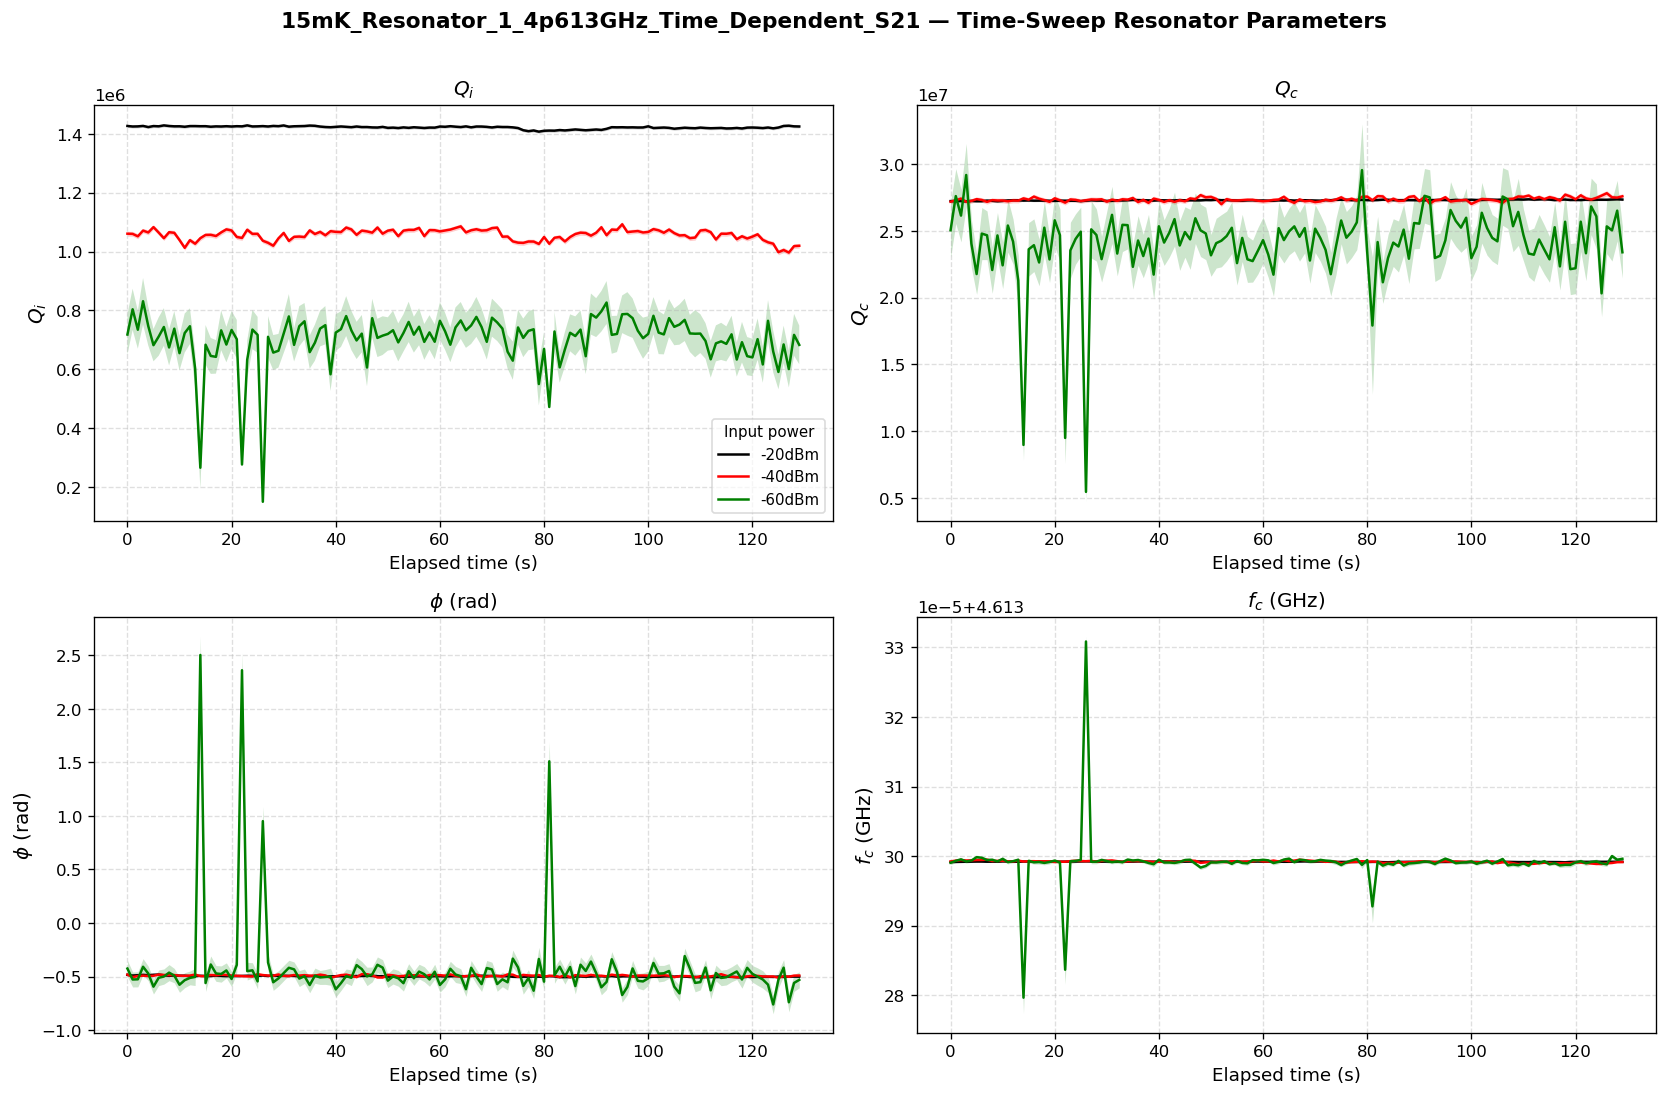

In [35]:
fig_ts = plot_time_sweeps(results, title_prefix=main_folder.name)

if SAVE_PLOTS:
    out_path = main_folder / "time_sweep_parameters.png"
    fig_ts.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out_path}")

plt.show()

### Power spectral density of noise

Saved -> C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_78_Line1-HTCav_01_CPW_w50g25_03\15mK_Resonator_1_4p613GHz_Time_Dependent_S21\psd_noise.png


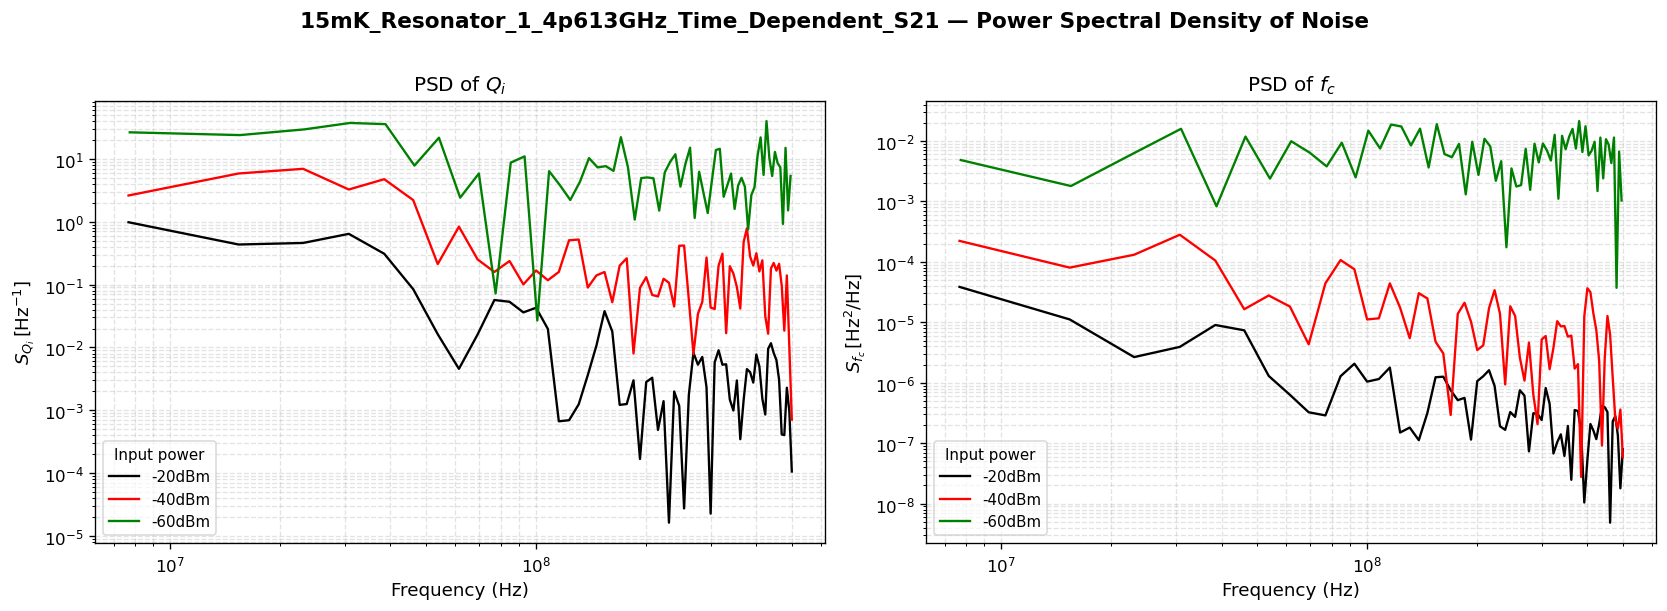

In [36]:
fig_psd = plot_psd(results, title_prefix=main_folder.name)

if SAVE_PLOTS:
    out_path = main_folder / "psd_noise.png"
    fig_psd.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out_path}")

plt.show()

### Save fitted parameters

In [37]:
if SAVE_CSVS:
    save_results(results, main_folder)

first_power = sorted(results.keys())[0]
print(f"\nPreview — {first_power}:")
display(results[first_power].head())

13:08:32 [INFO] Saved -> C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_78_Line1-HTCav_01_CPW_w50g25_03\15mK_Resonator_1_4p613GHz_Time_Dependent_S21\fitted_params\-20dBm.csv
13:08:32 [INFO] Saved -> C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_78_Line1-HTCav_01_CPW_w50g25_03\15mK_Resonator_1_4p613GHz_Time_Dependent_S21\fitted_params\-40dBm.csv
13:08:32 [INFO] Saved -> C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_78_Line1-HTCav_01_CPW_w50g25_03\15mK_Resonator_1_4p613GHz_Time_Dependent_S21\fitted_params\-60dBm.csv



Preview — -20dBm:


,timestamp,Qi,Qi_err,Qc,Qc_err,phi,phi_err,fc,fc_err
0,1970-01-01 00:00:00+00:00,1.426578e+06,5038.044435,2.721796e+07,76859.683622,-0.484100,0.003052,4.613299,6.474236e-09
1,1970-01-01 00:00:01+00:00,1.424769e+06,5007.779967,2.722177e+07,76509.456634,-0.490298,0.003041,4.613299,6.449074e-09
2,1970-01-01 00:00:02+00:00,1.425200e+06,5163.887056,2.722597e+07,78862.242419,-0.486744,0.003133,4.613299,6.648744e-09
3,1970-01-01 00:00:03+00:00,1.426779e+06,5022.550556,2.719970e+07,76529.078607,-0.484196,0.003042,4.613299,6.453162e-09
4,1970-01-01 00:00:04+00:00,1.422876e+06,5154.727654,2.723507e+07,78883.704629,-0.487257,0.003134,4.613299,6.659958e-09
